In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [ ]:
## filtruje tylko kontrast do dali
df_ca = df[df["Question"] == "Contrast sensitivity"]
## uwzglednienie tylko surowych danych, a nie prezliczonych do norm wiekowych
df_ca = df_ca[df_ca["Data_Value_Type"] == "Crude Prevalence"]
## Sprzątanie danych 
### usuwanie wierszy gdzie nie ma danych
df_ca = df_ca.dropna(subset=["Data_Value", "Age", "Response"])
### usuwanie "all ages" i wieku "65+"
df_ca = df_ca[df_ca["Age"] != "All ages"]
df_ca = df_ca[df_ca["Age"] != "65 years and older"]
### porządkowanie wieku w odpowiedniej kolejności
age_order = ["65-69 years", "70-74 years", "75-79 years", "80-84 years", "85-89 years", "90 years and older"]
df_ca["Age"] = pd.Categorical(df_ca["Age"], categories=age_order, ordered=True)

print(df_ca.head(5))


    YearStart  YearEnd StateAbbr LocationAbbr LocationDesc GeographicLevel  \
9        2022     2022        US           US     National        National   
10       2022     2022        US           US     National        National   
13       2022     2022        US           US     National        National   
16       2022     2022        US           US     National        National   
17       2022     2022        US           US     National        National   

   DataSource            Topic              Category              Question  \
9       NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
10      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
13      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
16      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
17      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   

    ... ResponseID DataValueTypeID      AgeID SexID RaceEthnic

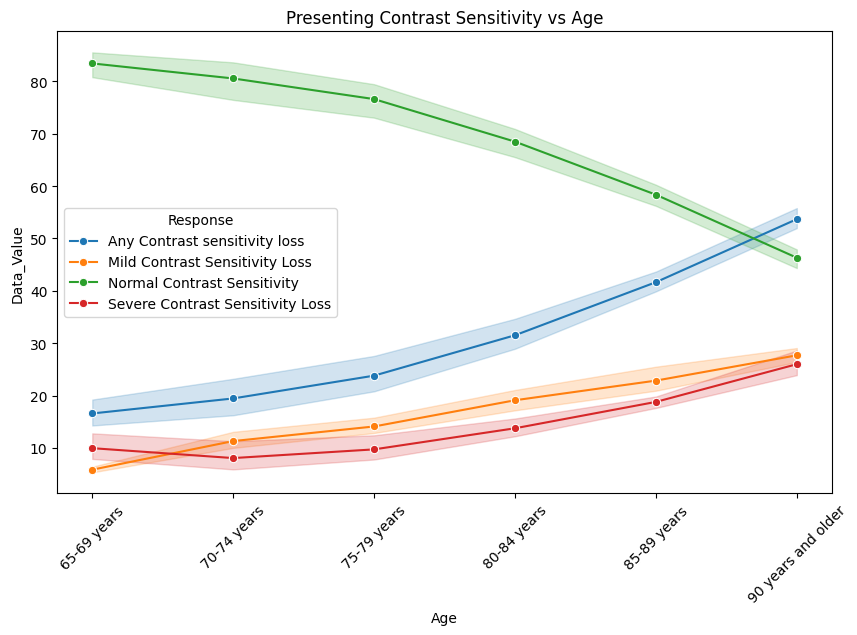

In [10]:
# tworzenie wykresu
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_ca,
    x="Age",
    y="Data_Value",
    hue="Response",
    marker="o"
)

plt.title("Presenting Contrast Sensitivity vs Age")
plt.xticks(rotation=45)
plt.show()

In [11]:
# inny test chi-kwadrat - CHYBA LEPSZY - DODAWANIE PROCENTOW WG AI CZYLI ZLE
from scipy.stats import chi2_contingency
# 1. Tworzenie tabeli kontyngencji (Crosstab)
# Wartości: Suma procentów (lub Sample_Size, jeśli masz tę kolumnę)
age_contingency = pd.crosstab(df_ca["Age"], 
                               df_ca["Response"], 
                               values=df_ca["Data_Value"], 
                               aggfunc="sum").fillna(0)

print("Tabela kontyngencji (Poczucie kontrastu vs wiek):")
print(age_contingency)

# 2. Wykonanie testu Chi-kwadrat
chi2_a, p_a, dof_a, expected_a = chi2_contingency(age_contingency)

print(f"\n--- Wyniki testu Chi-kwadrat dla wieku ---")
print(f"Statystyka Chi2: {chi2_a:.4f}")
print(f"Wartość p: {p_a:.4e}")
print(f"Stopnie swobody: {dof_a}")

# 3. Interpretacja
if p_a < 0.05:
    print("\nInterpretacja: Istnieje silna zależność między wiekiem a wrażliwością na kontrast.")
else:
    print("\nInterpretacja: Nie stwierdzono istotnej zależności rozkładu wrażliwości na kontrast od wieku.")

Tabela kontyngencji (Poczucie kontrastu vs wiek):
Response            Any Contrast sensitivity loss  \
Age                                                 
65-69 years                                182.43   
70-74 years                                213.98   
75-79 years                                261.86   
80-84 years                                283.66   
85-89 years                                374.84   
90 years and older                         536.83   

Response            Mild Contrast Sensitivity Loss  \
Age                                                  
65-69 years                                  35.12   
70-74 years                                 113.14   
75-79 years                                 155.13   
80-84 years                                 191.08   
85-89 years                                 205.72   
90 years and older                          276.89   

Response            Normal Contrast Sensitivity  \
Age                                      

In [12]:
# 1. Oczyszczanie danych
# Usuwamy 'Any Contrast sensitivity loss', aby uniknąć dublowania osób w grupach
# Usuwamy też wiersze, gdzie NonWeightedSample jest puste
df_clean = df_ca[
    (~df_ca["Response"].isin(['Any Contrast sensitivity loss'])) & 
    (df_ca["NonWeightedSample"].notna())
].copy()

# 1. Tworzymy tabelę kontyngencji używając ŚREDNIEJ (mean) dla liczebności grupy
# To zapobiegnie wielokrotnemu dodawaniu tych samych osób z NonWeightedSample
age_group_sizes = pd.crosstab(
    df_clean["Age"], 
    df_clean["Response"], 
    values=df_clean["NonWeightedSample"], 
    aggfunc="mean" # Bierzemy realną wielkość grupy, nie sumujemy jej
).fillna(0)

# 2. Teraz nakładamy na to procenty (Data_Value)
# Tworzymy tabelę procentów
percentages = pd.crosstab(
    df_clean["Age"], 
    df_clean["Response"], 
    values=df_clean["Data_Value"], 
    aggfunc="mean"
).fillna(0)

# 3. Finalna tabela: (Wielkość grupy * procent) / 100
age_contingency = (percentages * age_group_sizes) / 100

# Teraz suma age_contingency.values.sum() powinna być bliska 6327

# 4. Wykonanie testu Chi-kwadrat
chi2_a, p_a, dof_a, expected_a = chi2_contingency(age_contingency)

# 5. Obliczenie V Craméra
def calculate_cramers_v(chi2, table):
    n = table.values.sum() # Suma wszystkich oszacowanych osób w tabeli
    r, k = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

v_cramera = calculate_cramers_v(chi2_a, age_contingency)

# Wyświetlanie wyników
print("Tabela kontyngencji (Szacowane liczby osób):")
print(age_contingency.round(1))

print(f"\n--- Analiza zależności (Wiek vs Kontrast) ---")
print(f"Statystyka Chi2: {chi2_a:.4f}")
print(f"Wartość p: {p_a:.4e}")
print(f"V Craméra: {v_cramera:.4f}")

# Interpretacja wyniku
if p_a > 0.05:
    print("Wynik: Brak istotnej statystycznie zależności.")
else:
    if v_cramera < 0.1:
        desc = "pomijalna"
    elif v_cramera < 0.3:
        desc = "słaba"
    elif v_cramera < 0.5:
        desc = "umiarkowana"
    else:
        desc = "silna"
    print(f"Wynik: Istotna statystycznie zależność o sile: {desc}.")

Tabela kontyngencji (Szacowane liczby osób):
Response            Mild Contrast Sensitivity Loss  \
Age                                                  
65-69 years                                   28.6   
70-74 years                                   61.1   
75-79 years                                   96.0   
80-84 years                                  116.4   
85-89 years                                   92.2   
90 years and older                            72.9   

Response            Normal Contrast Sensitivity  \
Age                                               
65-69 years                               281.6   
70-74 years                               402.0   
75-79 years                               480.8   
80-84 years                               455.3   
85-89 years                               235.5   
90 years and older                        122.0   

Response            Severe Contrast Sensitivity Loss  
Age                                                   
65-

In [13]:
#ostateczne
#Ze względu na strukturę danych wejściowych (wartości procentowe przypisane do grup), dokonano rekonstrukcji liczebności bezwzględnych poprzez przemnożenie procentowego udziału odpowiedzi przez wielkość próby (Non-Weighted Sample). W celu uniknięcia błędnego zwielokrotnienia liczebności wynikającego z powtarzających się rekordów w bazie, zastosowano agregację metodą średniej arytmetycznej dla każdej komórki tabeli kontyngencji.”

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# =================================================================
# 1. PRZYGOTOWANIE I OCZYSZCZANIE DANYCH
# =================================================================

# Odfiltrowanie zagregowanych odpowiedzi (uniknięcie duplikowania osób)
# oraz usunięcie rekordów z brakującymi danymi o wielkości próby
exclude_responses = ['Any Contrast sensitivity loss']
df_filtered = df_ca[
    (~df_ca["Response"].isin(exclude_responses)) & 
    (df_ca["NonWeightedSample"].notna())
].copy()

# =================================================================
# 2. KONSTRUKCJA TABELI KONTYNGENCJI (SZACOWANIE LICZEBNOŚCI)
# =================================================================

# Wyznaczamy średnią wielkość grupy dla każdej kategorii (zabezpieczenie przed duplikacją)
group_sizes = pd.crosstab(
    df_filtered["Age"], 
    df_filtered["Response"], 
    values=df_filtered["NonWeightedSample"], 
    aggfunc="mean"
).fillna(0)

# Wyznaczamy średnie wartości procentowe dla danej kategorii
percentages = pd.crosstab(
    df_filtered["Age"], 
    df_filtered["Response"], 
    values=df_filtered["Data_Value"], 
    aggfunc="mean"
).fillna(0)

# Rekonstrukcja tabeli kontyngencji: przeliczenie procentów na liczby osób
# (Procent * Wielkość Grupy) / 100
age_contingency = (percentages * group_sizes) / 100

# =================================================================
# 3. ANALIZA STATYSTYCZNA
# =================================================================

# Wykonanie testu niezależności Chi-kwadrat Pearsona
chi2_stat, p_value, dof, expected_freq = chi2_contingency(age_contingency)

def calculate_cramers_v(chi2, table):
    """Oblicza współczynnik V Craméra dla siły zależności."""
    n = table.values.sum()  # Całkowita liczebność próby
    r, k = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

v_cramera = calculate_cramers_v(chi2_stat, age_contingency)

# =================================================================
# 4. PREZENTACJA WYNIKÓW
# =================================================================

print("TABELA KONTYNGENCJI (Szacowane liczby osób):")
print(age_contingency.round(1))
print("-" * 50)
print(f"ANALIZA STATYSTYCZNA: Wiek vs Czułość kontrastu")
print(f"Liczebność próby (N):    {age_contingency.values.sum():.0f}")
print(f"Statystyka Chi2:         {chi2_stat:.4f}")
print(f"Wartość p:               {p_value:.4e}")
print(f"Stopnie swobody:         {dof}")
print(f"Współczynnik V Craméra:  {v_cramera:.4f}")

# Interpretacja jakościowa
if p_value < 0.05:
    if v_cramera < 0.1:
        strength = "pomijalna"
    elif v_cramera < 0.3:
        strength = "słaba"
    elif v_cramera < 0.5:
        strength = "umiarkowana"
    else:
        strength = "silna"
    print(f"Wniosek: Zależność istotna statystycznie, siła związku: {strength}.")
else:
    print("Wniosek: Brak istotnych statystycznie podstaw do odrzucenia hipotezy o niezależności.")

TABELA KONTYNGENCJI (Szacowane liczby osób):
Response            Mild Contrast Sensitivity Loss  \
Age                                                  
65-69 years                                   28.6   
70-74 years                                   61.1   
75-79 years                                   96.0   
80-84 years                                  116.4   
85-89 years                                   92.2   
90 years and older                            72.9   

Response            Normal Contrast Sensitivity  \
Age                                               
65-69 years                               281.6   
70-74 years                               402.0   
75-79 years                               480.8   
80-84 years                               455.3   
85-89 years                               235.5   
90 years and older                        122.0   

Response            Severe Contrast Sensitivity Loss  
Age                                                   
65-